# BT1 – Phân tích thời gian thực thi chương trình

## Câu 1
Sinh `N` phần tử đầu tiên của dãy Fibonacci bằng:
- Thuật toán đệ quy.
- Thuật toán vòng lặp.

## Câu 2
Đo thời gian chạy khi `N` tăng từ 1 đến 40 và biểu diễn bằng bảng, đồ thị.

## Câu 3
Dựa trên kết quả thực nghiệm, đánh giá khả năng chạy của hai thuật toán và xác định giới hạn xử lý theo thời gian quy định.

### Thuật toán

Với dãy Fibonacci:

`F(0) = 0`, `F(1) = 1`

`F(n) = F(n-1) + F(n-2)`

- Đệ quy: gọi lại chính hàm Fibonacci để tính từng phần tử.
- Vòng lặp: tính lần lượt từ hai phần tử trước đó.

In [1]:
%%writefile fibonacci.cpp
#include <iostream>
#include <vector>
#include <chrono>
#include <iomanip>

using namespace std;

long long fibRecursive(int n) {
    if (n <= 1)
        return n;
    return fibRecursive(n - 1) + fibRecursive(n - 2);
}

vector<long long> generateFibRecursive(int N) {
    vector<long long> result;
    for (int i = 0; i < N; ++i)
        result.push_back(fibRecursive(i));
    return result;
}

vector<long long> generateFibIterative(int N) {
    if (N <= 0)
        return {};

    if (N == 1)
        return {0};

    vector<long long> result = {0, 1};

    for (int i = 2; i < N; ++i)
        result.push_back(result[i - 1] + result[i - 2]);

    return result;
}

void measure(int maxN) {
    cout << "N,Iterative_ms,Recursive_ms\n";

    for (int N = 1; N <= maxN; ++N) {
        auto start = chrono::high_resolution_clock::now();
        volatile auto iterative = generateFibIterative(N);
        auto end = chrono::high_resolution_clock::now();

        double iterativeTime =
            chrono::duration<double, milli>(end - start).count();

        start = chrono::high_resolution_clock::now();
        volatile auto recursive = generateFibRecursive(N);
        end = chrono::high_resolution_clock::now();

        double recursiveTime =
            chrono::duration<double, milli>(end - start).count();

        cout << fixed << setprecision(6)
             << N << ","
             << iterativeTime << ","
             << recursiveTime << "\n";
    }
}

int main() {
    measure(40);
    return 0;
}


Writing fibonacci.cpp


In [2]:
!g++ -O0 -std=c++17 fibonacci.cpp -o fibonacci

## Câu 2 – Kết quả đo thực nghiệm

Chương trình dưới đây được chạy trực tiếp trên Runtime hiện tại của Google Colab. Kết quả được lưu lại và dùng chính dữ liệu đó để lập bảng và đồ thị.

In [3]:
!./fibonacci | tee fibonacci_results.csv

N,Iterative_ms,Recursive_ms
1,0.001853,0.000817
2,0.000512,0.000759
3,0.000664,0.000959
4,0.000728,0.000919
5,0.000961,0.003439
6,0.000994,0.001466
7,0.000986,0.001578
8,0.001016,0.001858
9,0.001448,0.002142
10,0.001436,0.002541
11,0.001488,0.003210
12,0.001517,0.004109
13,0.001547,0.005597
14,0.001623,0.008088
15,0.001652,0.011961
16,0.001704,0.018359
17,0.002017,0.028871
18,0.001997,0.045380
19,0.002112,0.149959
20,0.003031,0.152480
21,0.003296,0.214483
22,0.002457,0.384716
23,0.004025,0.650835
24,0.003145,0.848821
25,0.002832,1.311481
26,0.002988,2.122961
27,0.003114,3.572508
28,0.004465,5.417282
29,0.003985,8.952402
30,0.003799,14.245142
31,0.003946,23.047316
32,0.004512,40.790061
33,0.006420,80.355606
34,0.005442,141.779687
35,0.006701,235.377202
36,0.007922,400.985632
37,0.008148,654.970013
38,0.008044,1074.737372
39,0.008570,1516.353295
40,0.007346,1837.267912


In [4]:
import pandas as pd

df = pd.read_csv("fibonacci_results.csv")
df

,N,Iterative_ms,Recursive_ms
0,1,0.001853,0.000817
1,2,0.000512,0.000759
2,3,0.000664,0.000959
3,4,0.000728,0.000919
4,5,0.000961,0.003439
5,6,0.000994,0.001466
6,7,0.000986,0.001578
7,8,0.001016,0.001858
8,9,0.001448,0.002142
9,10,0.001436,0.002541


## Đồ thị thời gian thực thi

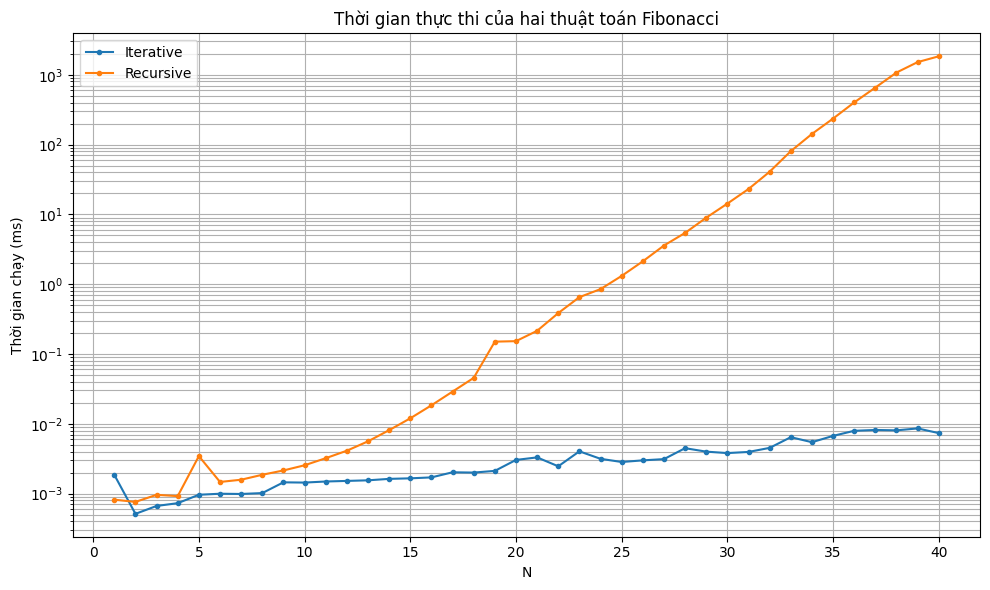

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df["N"], df["Iterative_ms"], marker="o", markersize=3, label="Iterative")
plt.plot(df["N"], df["Recursive_ms"], marker="o", markersize=3, label="Recursive")
plt.yscale("log")
plt.xlabel("N")
plt.ylabel("Thời gian chạy (ms)")
plt.title("Thời gian thực thi của hai thuật toán Fibonacci")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()

### Nhận xét Câu 2

- Thời gian của thuật toán vòng lặp tăng chậm khi `N` tăng.
- Thời gian của thuật toán đệ quy tăng rất nhanh.
- Khi `N` nhỏ, chênh lệch thời gian chưa rõ rệt; khi `N` tăng, đệ quy nhanh chóng trở nên kém hiệu quả.
- Đồ thị dùng trục thời gian dạng logarit để thể hiện đồng thời hai xu hướng.

## Câu 3 – Đánh giá khả năng chạy

Để đánh giá định lượng, đặt giới hạn thời gian thực thi là **1 giây**. Nếu đề bài yêu cầu một giới hạn khác, chỉ cần thay giá trị `TIME_LIMIT_MS` bên dưới.

In [6]:
TIME_LIMIT_MS = 1000

iterative_ok = df[df["Iterative_ms"] <= TIME_LIMIT_MS]
recursive_ok = df[df["Recursive_ms"] <= TIME_LIMIT_MS]

max_iterative = int(iterative_ok["N"].max()) if not iterative_ok.empty else None
max_recursive = int(recursive_ok["N"].max()) if not recursive_ok.empty else None

print(f"Giới hạn thời gian: {TIME_LIMIT_MS} ms")
print(f"N lớn nhất của Iterative trong giới hạn: {max_iterative}")
print(f"N lớn nhất của Recursive trong giới hạn: {max_recursive}")

Giới hạn thời gian: 1000 ms
N lớn nhất của Iterative trong giới hạn: 40
N lớn nhất của Recursive trong giới hạn: 37


### Kết luận

Thuật toán vòng lặp có độ phức tạp thời gian `O(N)`, vì vậy thời gian thực thi tăng tương đối chậm theo `N` và có khả năng xử lý các giá trị `N` lớn hơn.

Thuật toán đệ quy Fibonacci trực tiếp có độ phức tạp thời gian theo cấp số nhân, xấp xỉ `O(2^N)`. Mỗi lần `N` tăng, số lần gọi hàm tăng rất nhanh nên thời gian thực thi tăng mạnh.

Kết quả thực nghiệm cho thấy thuật toán vòng lặp hiệu quả hơn rõ rệt so với thuật toán đệ quy khi `N` lớn. Vì vậy, nếu yêu cầu xử lý số lượng phần tử Fibonacci lớn hoặc phải đáp ứng giới hạn thời gian, nên sử dụng thuật toán vòng lặp.